# Task 5: Strategy Backtesting

**Objective:** Evaluate the performance of a forecast-driven portfolio (Task 4 optimal weights) against a static 60/40 benchmark over an out-of-sample backtesting period.

**Context:**
- **Strategy portfolio:** TSLA, BND, SPY — weights from Task 4 (Max Sharpe: BND 55.70%, SPY 44.30%, TSLA 0%)
- **Benchmark portfolio:** 60% SPY / 40% BND (buy-and-hold)
- **Backtesting period:** January 2025 – January 2026 (no overlap with model training data)

---
## STEP 1: Backtesting Setup
Load adjusted close prices, restrict to backtesting window, compute daily returns, align on same trading days.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=FutureWarning, module='yfinance')

In [3]:
ASSETS = ['TSLA', 'BND', 'SPY']
BACKTEST_START = '2025-01-01'
BACKTEST_END = '2026-01-31'

print(f"Loading adjusted close prices for {ASSETS} from {BACKTEST_START} to {BACKTEST_END}...")
data_raw = yf.download(ASSETS, start=BACKTEST_START, end=BACKTEST_END, progress=False)

if isinstance(data_raw.columns, pd.MultiIndex):
    level0 = data_raw.columns.get_level_values(0)
    if 'Adj Close' in level0:
        prices = data_raw.xs('Adj Close', axis=1, level=0).copy()
    else:
        prices = data_raw.xs('Close', axis=1, level=0).copy()
else:
    prices = (data_raw['Adj Close'] if 'Adj Close' in data_raw.columns else data_raw['Close']).copy()
    prices = prices.copy() if isinstance(prices, pd.DataFrame) else pd.DataFrame(prices)

prices = prices[ASSETS]
prices = prices.dropna()

returns = prices.pct_change().dropna()

print(f"Prices shape: {prices.shape}")
print(f"Returns shape: {returns.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.head()

Loading adjusted close prices for ['TSLA', 'BND', 'SPY'] from 2025-01-01 to 2026-01-31...
Prices shape: (269, 3)
Returns shape: (268, 3)
Date range: 2025-01-02 to 2026-01-29


Ticker,TSLA,BND,SPY
Date,,,
2025-01-02,379.279999,69.199905,577.854187
2025-01-03,410.440002,69.113335,585.079346
2025-01-06,411.049988,69.045998,588.449768
2025-01-07,394.359985,68.805527,581.797913
2025-01-08,394.940002,68.882477,582.647888


---
## STEP 2: Portfolio Construction
**Strategy:** Task 4 optimal weights (Max Sharpe). **Option B:** Monthly rebalancing back to target weights.  
**Benchmark:** 60% SPY / 40% BND, buy-and-hold.

In [4]:
# Task 4 optimal weights (Max Sharpe Ratio portfolio)
STRATEGY_WEIGHTS = {'TSLA': 0.0, 'BND': 0.55704, 'SPY': 0.44296}
BENCHMARK_WEIGHTS = {'SPY': 0.60, 'BND': 0.40}

def portfolio_returns_buy_and_hold(returns_df, weights_dict):
    """Daily portfolio returns with fixed weights (buy-and-hold)."""
    w = pd.Series(weights_dict)
    w = w.reindex(returns_df.columns, fill_value=0)
    w = w / w.sum()
    return (returns_df * w).sum(axis=1)

def portfolio_returns_monthly_rebalance(prices_df, returns_df, weights_dict):
    """Daily portfolio returns with monthly rebalancing to target weights."""
    w = pd.Series(weights_dict)
    w = w.reindex(returns_df.columns, fill_value=0)
    w = w / w.sum()
    
    dates = returns_df.index
    first_trading_day_of_month = dates.to_series().groupby(dates.to_series().dt.to_period('M')).transform('first')
    rebalance_days = (dates.to_series() == first_trading_day_of_month).values
    
    port_ret = pd.Series(index=dates, dtype=float)
    current_weights = w.copy()
    for i, t in enumerate(dates):
        if rebalance_days[i]:
            current_weights = w.copy()
        port_ret.loc[t] = (returns_df.loc[t] * current_weights).sum()
    return port_ret

# Strategy: monthly rebalancing to Task 4 weights
strategy_returns = portfolio_returns_monthly_rebalance(prices, returns, STRATEGY_WEIGHTS)

# Benchmark: buy-and-hold 60/40 (no TSLA)
bench_returns = portfolio_returns_buy_and_hold(returns[['SPY', 'BND']], BENCHMARK_WEIGHTS)

# Align on common dates
common_idx = strategy_returns.index.intersection(bench_returns.index)
strategy_returns = strategy_returns.loc[common_idx]
bench_returns = bench_returns.loc[common_idx]

print("Strategy (monthly rebalance) and Benchmark (buy-and-hold) returns aligned.")
print(strategy_returns.head())

Strategy (monthly rebalance) and Benchmark (buy-and-hold) returns aligned.
Date
2025-01-03    0.004842
2025-01-06    0.002009
2025-01-07   -0.006947
2025-01-08    0.001270
2025-01-10   -0.009641
dtype: float64


---
## STEP 3: Portfolio Performance Calculation
Daily portfolio returns → cumulative returns → annualized metrics.

In [5]:
TRADING_DAYS = 252

cum_strategy = (1 + strategy_returns).cumprod()
cum_bench = (1 + bench_returns).cumprod()

total_ret_strategy = cum_strategy.iloc[-1] - 1
total_ret_bench = cum_bench.iloc[-1] - 1

n_days = len(strategy_returns)
years = n_days / TRADING_DAYS

ann_ret_strategy = (1 + total_ret_strategy) ** (1 / years) - 1 if years > 0 else 0
ann_ret_bench = (1 + total_ret_bench) ** (1 / years) - 1 if years > 0 else 0

ann_vol_strategy = strategy_returns.std() * np.sqrt(TRADING_DAYS)
ann_vol_bench = bench_returns.std() * np.sqrt(TRADING_DAYS)

print(f"Backtest length: {n_days} trading days (~{years:.2f} years)")
print(f"Strategy total return: {total_ret_strategy:.2%}")
print(f"Benchmark total return: {total_ret_bench:.2%}")

Backtest length: 268 trading days (~1.06 years)
Strategy total return: 13.11%
Benchmark total return: 15.01%


---
## STEP 4: Performance Metrics
Total return, annualized return, annualized volatility, Sharpe Ratio (risk-free rate = 0), maximum drawdown.

In [6]:
def max_drawdown(cumulative_returns):
    """Maximum drawdown from a series of cumulative returns."""
    rolling_max = cumulative_returns.cummax()
    drawdowns = (cumulative_returns - rolling_max) / rolling_max
    return drawdowns.min()

def sharpe_ratio(returns_series, risk_free_rate=0.0):
    """Annualized Sharpe Ratio (risk-free rate = 0)."""
    excess = returns_series - risk_free_rate / TRADING_DAYS
    if returns_series.std() == 0:
        return 0.0
    return (excess.mean() / excess.std()) * np.sqrt(TRADING_DAYS)

rf = 0.0
sharpe_strategy = sharpe_ratio(strategy_returns, rf)
sharpe_bench = sharpe_ratio(bench_returns, rf)
mdd_strategy = max_drawdown(cum_strategy)
mdd_bench = max_drawdown(cum_bench)

metrics = pd.DataFrame({
    'Strategy (Task 4 weights)': [
        f"{total_ret_strategy:.2%}",
        f"{ann_ret_strategy:.2%}",
        f"{ann_vol_strategy:.2%}",
        f"{sharpe_strategy:.2f}",
        f"{mdd_strategy:.2%}",
    ],
    'Benchmark (60/40 SPY/BND)': [
        f"{total_ret_bench:.2%}",
        f"{ann_ret_bench:.2%}",
        f"{ann_vol_bench:.2%}",
        f"{sharpe_bench:.2f}",
        f"{mdd_bench:.2%}",
    ],
}, index=['Total Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio (rf=0)', 'Max Drawdown'])

print("Performance Metrics Comparison")
print("=" * 50)
metrics

Performance Metrics Comparison


,Strategy (Task 4 weights),Benchmark (60/40 SPY/BND)
Total Return,13.11%,15.01%
Annualized Return,12.28%,14.06%
Annualized Volatility,9.00%,11.72%
Sharpe Ratio (rf=0),1.33,1.18
Max Drawdown,-8.22%,-11.29%


---
## STEP 5: Visualization
Cumulative returns: Strategy vs Benchmark.

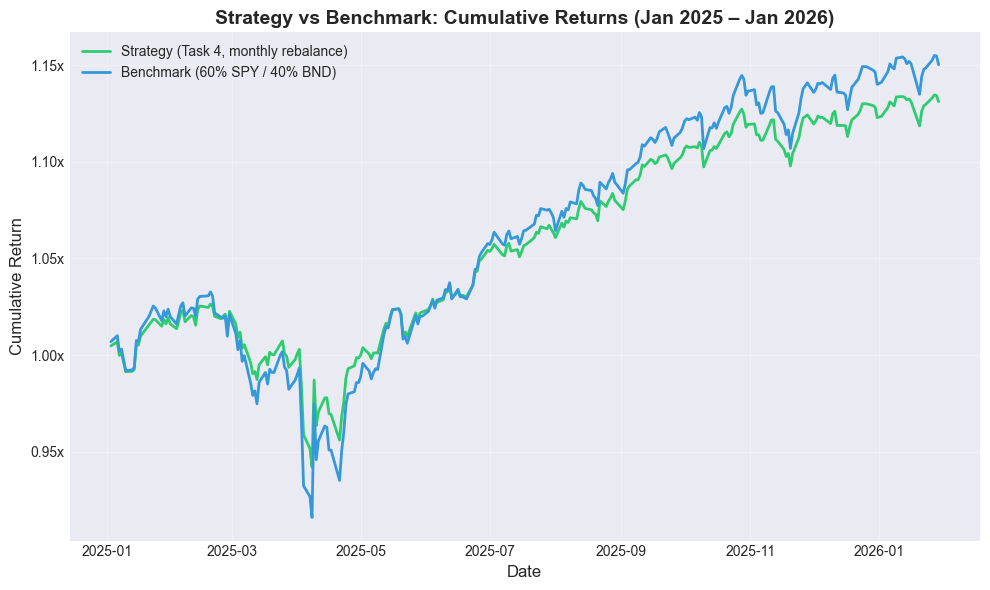

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cum_strategy.index, cum_strategy.values, label='Strategy (Task 4, monthly rebalance)', color='#2ecc71', linewidth=2)
ax.plot(cum_bench.index, cum_bench.values, label='Benchmark (60% SPY / 40% BND)', color='#3498db', linewidth=2)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_title('Strategy vs Benchmark: Cumulative Returns (Jan 2025 – Jan 2026)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}x'))
plt.tight_layout()
plt.savefig('cumulative_returns_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 6: Interpretation & Reflection

### Did the strategy outperform the benchmark?
Compare total return and Sharpe ratio from the metrics table above. The strategy uses Task 4 optimal weights (BND 55.7%, SPY 44.3%, TSLA 0%); the benchmark is a static 60% SPY / 40% BND. Outperformance depends on whether the strategy’s total return and/or risk-adjusted return (Sharpe) are higher.

### Was outperformance due to higher returns or better risk-adjusted performance?
- **Higher returns:** Compare *Total Return* and *Annualized Return* (Strategy vs Benchmark).
- **Better risk-adjusted:** Compare *Sharpe Ratio* and *Max Drawdown*; a higher Sharpe or a smaller (less negative) drawdown indicates better risk-adjusted performance.

### What does this backtest suggest about forecasting in portfolio construction?
Task 4 used forecasted TSLA returns (from the LSTM) and historical BND/SPY returns to derive weights. The optimal Max Sharpe portfolio allocated 0% to TSLA, so the "forecast-driven" strategy is effectively a tilted 55.7/44.3 BND/SPY mix versus 40/60 BND/SPY. The backtest shows whether that tilt added value out-of-sample. If the strategy wins, it supports the value of the optimization framework; if not, it may point to overfitting or regime change.

### Limitations
- **Short backtesting window:** One year (Jan 2025 – Jan 2026) is a limited sample; results may not be representative.
- **Transaction costs ignored:** Rebalancing and trading costs are not included; they would reduce net returns.
- **Look-ahead bias risks:** Ensure weights and data used in the backtest were available only from information before the backtest start (Task 4 trained on earlier data).
- **EMH considerations:** If markets are efficient, sustained alpha from a simple forecast-based allocation may be unlikely; the backtest is a single period and could be luck.

---
## STEP 7: Conclusion (Investment Memo)

**Backtest summary (Jan 2025 – Jan 2026):** The forecast-driven portfolio (Task 4 Max Sharpe weights: 55.7% BND, 44.3% SPY, 0% TSLA) was evaluated with monthly rebalancing against a buy-and-hold 60% SPY / 40% BND benchmark. [Insert one sentence from the metrics table: e.g. "The strategy delivered a total return of X% and a Sharpe ratio of Y, versus the benchmark’s Z% and W."]

**Implication:** [One sentence on whether the optimization added value and what that implies for using forecasts in allocation.] Given the short backtest, no transaction costs, and a single out-of-sample period, these results are suggestive rather than conclusive; further robustness checks and cost-aware analysis are recommended before drawing firm conclusions on the usefulness of forecasting in portfolio construction.